### Quadratic Equation-- Conditional Workflow

In [58]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [14]:
#defining state class
class QaudState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    descrimenant:float
    result:str

In [69]:
#creating show equation node
def show_equation(state:QaudState):
    equation = f"({state['a']}x2) +({state['b']})x +({state['c']})"
    return {"equation":equation}

#creating show equation node
def calculate_discr(state:QaudState):
    descrimenant = state['b']**2 -(4*state['a']*state['c'])
    return {"descrimenant":descrimenant}

def real_roots(state:QaudState):
    root1 = round((-state['b']+state['descrimenant']**0.5)/2*state['a'],2)
    root2 = round((-state['b']-state['descrimenant']**0.5)/2*state['a'],2)

    result = f"The roots are {root1} and {root2}"

    return {"result":result}

def repeated_roots(state:QaudState):
    root = (-state['b'])/(2*state['a'])

    result = f"Only Repeated root is {root}"

    return {"result":result}

def no_roots(state:QaudState):

    result = f"No real Roots"

    return {"result":result}

def check_condition(state:QaudState) ->Literal['real_roots','repeated_roots','no_roots']:
    if state['descrimenant']>0:
        return "real_roots"
    elif state['descrimenant']<0:
        return "no_roots"
    else:
        return "repeated_roots"

In [70]:
#graph defining
graph = StateGraph(QaudState)

#creating nodes
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discr',calculate_discr)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_roots',no_roots)

#creating edges
graph.add_edge(START,"show_equation")
graph.add_edge('show_equation','calculate_discr')
graph.add_conditional_edges("calculate_discr",check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_roots',END)

In [71]:
workflow = graph.compile()

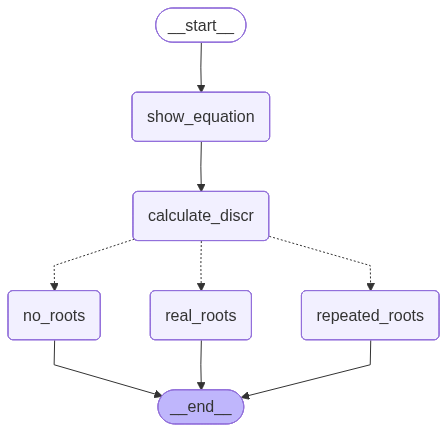

In [72]:
workflow

In [76]:
initial_state = {'a':2,'b':4,'c':-8}
res = workflow.invoke(initial_state)


In [78]:
res

{'a': 2,
 'b': 4,
 'c': -8,
 'equation': '(2x2) +(4)x +(-8)',
 'descrimenant': 80,
 'result': 'The roots are 4.94 and -12.94'}

In [79]:
res['result']

'The roots are 4.94 and -12.94'